In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
import seaborn as sns
import time as time_module
import pandas as pd
import torch

from scipy.integrate import odeint
from scipy.optimize import least_squares, minimize
from tqdm import tqdm

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
from sklearn.gaussian_process.kernels import Kernel, StationaryKernelMixin, Hyperparameter

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.integrate import odeint

> problem settings

In [2]:
from _config import get_prms
from _trainer import Trainer

# problem settings : exponential, logistic, target cell-limited 
name = 'log' # 'exp', 'log', 'virus'
dist_type = 'tri' # 'uni', 'bi', 'tri'

# hyperparameter settings (prms[0]:DE, prms[1]:hyperPINN, prms[2]:WGAN)
prms = get_prms(name, dist_type=dist_type) # DE / hyperPINN / WGAN settings
prms[1]['sc'] = False
#prms[2]['num_noised'] = 12 # Insert the number of real paramaters from the each nodes with noise 
#prms[2]['num_gen_ratio'] = 1 # Insert the ratio : fake data/real data 
prms[2]['num_cut'] = 0 # Insert the number of censored time for each mode which is randomly determined via numpy seed.
prms

[{'outputs': ['Y'],
  'param_names': ['r', 'K'],
  'num_p': 2,
  'num_eq': 1,
  't_range': [0, 20],
  'init': [1e-05],
  'p_range': [[1, 5], [0.2, 1.5]]},
 {'width_hyp': 64,
  'depth_hyp': 4,
  'width_tru': 32,
  'num_chunks_in': 0,
  'act': 'tanh',
  'lr': 5e-05,
  'Nt': 100,
  'Np': 200,
  'batch_size': 10000,
  'init_noise_scale': 0.2,
  'beta': 0.01,
  'tol': 0.0005,
  'sc': False,
  'deeponet': False,
  'num_epochs': 10000},
 {'num_bins': 5,
  'plow': 0.97,
  'phigh': 1.03,
  'num_noised': 12,
  'modes': array([[1.6, 0.6],
         [4. , 0.9],
         [2. , 1.3]]),
  'num_gen_ratio': 1,
  'num_gen_plot': 1000,
  'data_noise_scale': 0.0,
  'init_noise_scale_wgan': 0.0,
  'num_cut': 0,
  'noise_dim': 16,
  'width': 64,
  'depth': 4,
  'lr_G': 0.0001,
  'lr_D': 0.0001,
  'ratio_G': 1,
  'num_gen_traj': -1,
  'center_penalty': False}]

cuda:0
[ total number of true data points : 180 ]


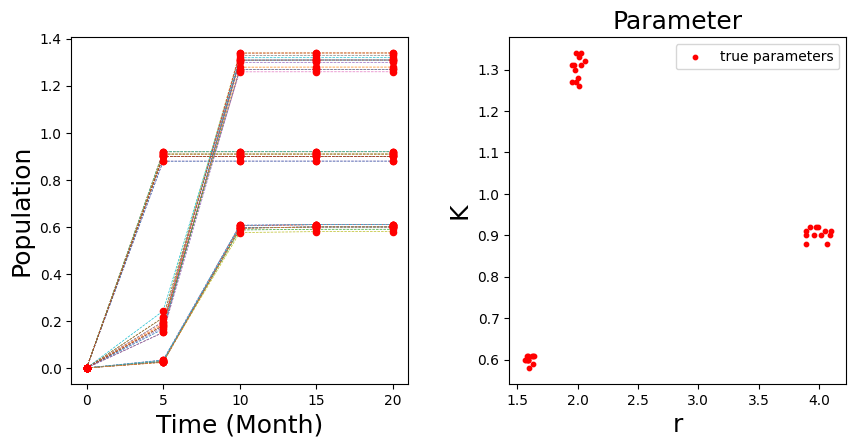

In [3]:
import torch

# devisce
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

seed = 1234
np.random.seed(seed)
torch.manual_seed(seed)

# get dataset : if you want real data 
real_data = None # None, 'Abeta40', 'Abeta42'
trainer = Trainer(name, prms, device=device)
modes_noisy, X_data, X_data_onehot = trainer.get_data_gan(real_data=real_data)

> train GP

In [4]:
num_eq = trainer.num_eq
num_bins = trainer.num_bins
t = trainer.t_numpy.reshape(-1)
traj_dict = {}
for ii in range(num_eq): 
    traj_dict[ii] = X_data[:,ii+1:ii+2].reshape(-1,num_bins).numpy()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


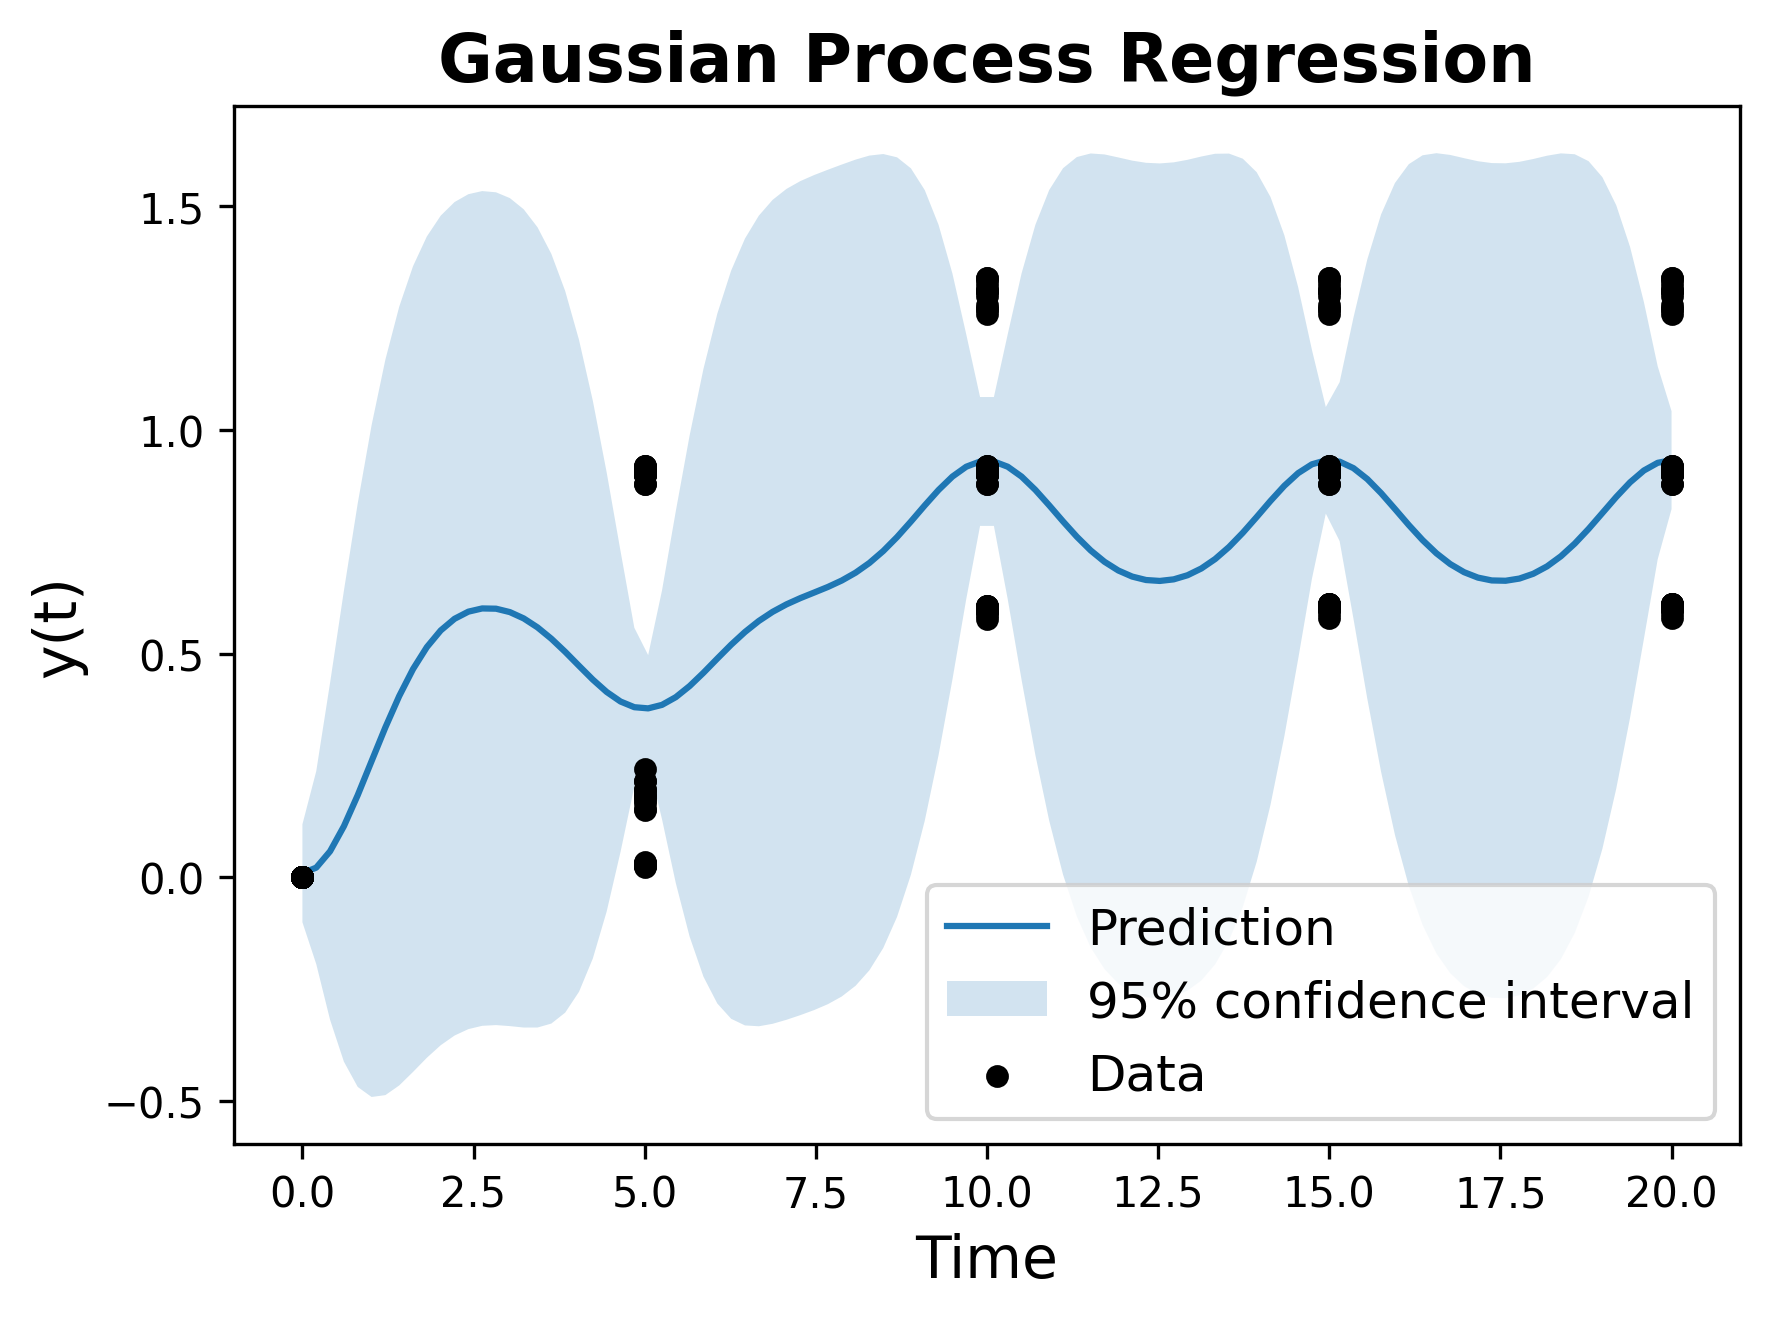

The code took 1.9997098445892334 seconds to run.


100%|██████████████████████████████████| 1000/1000 [00:00<00:00, 1923110.50it/s]


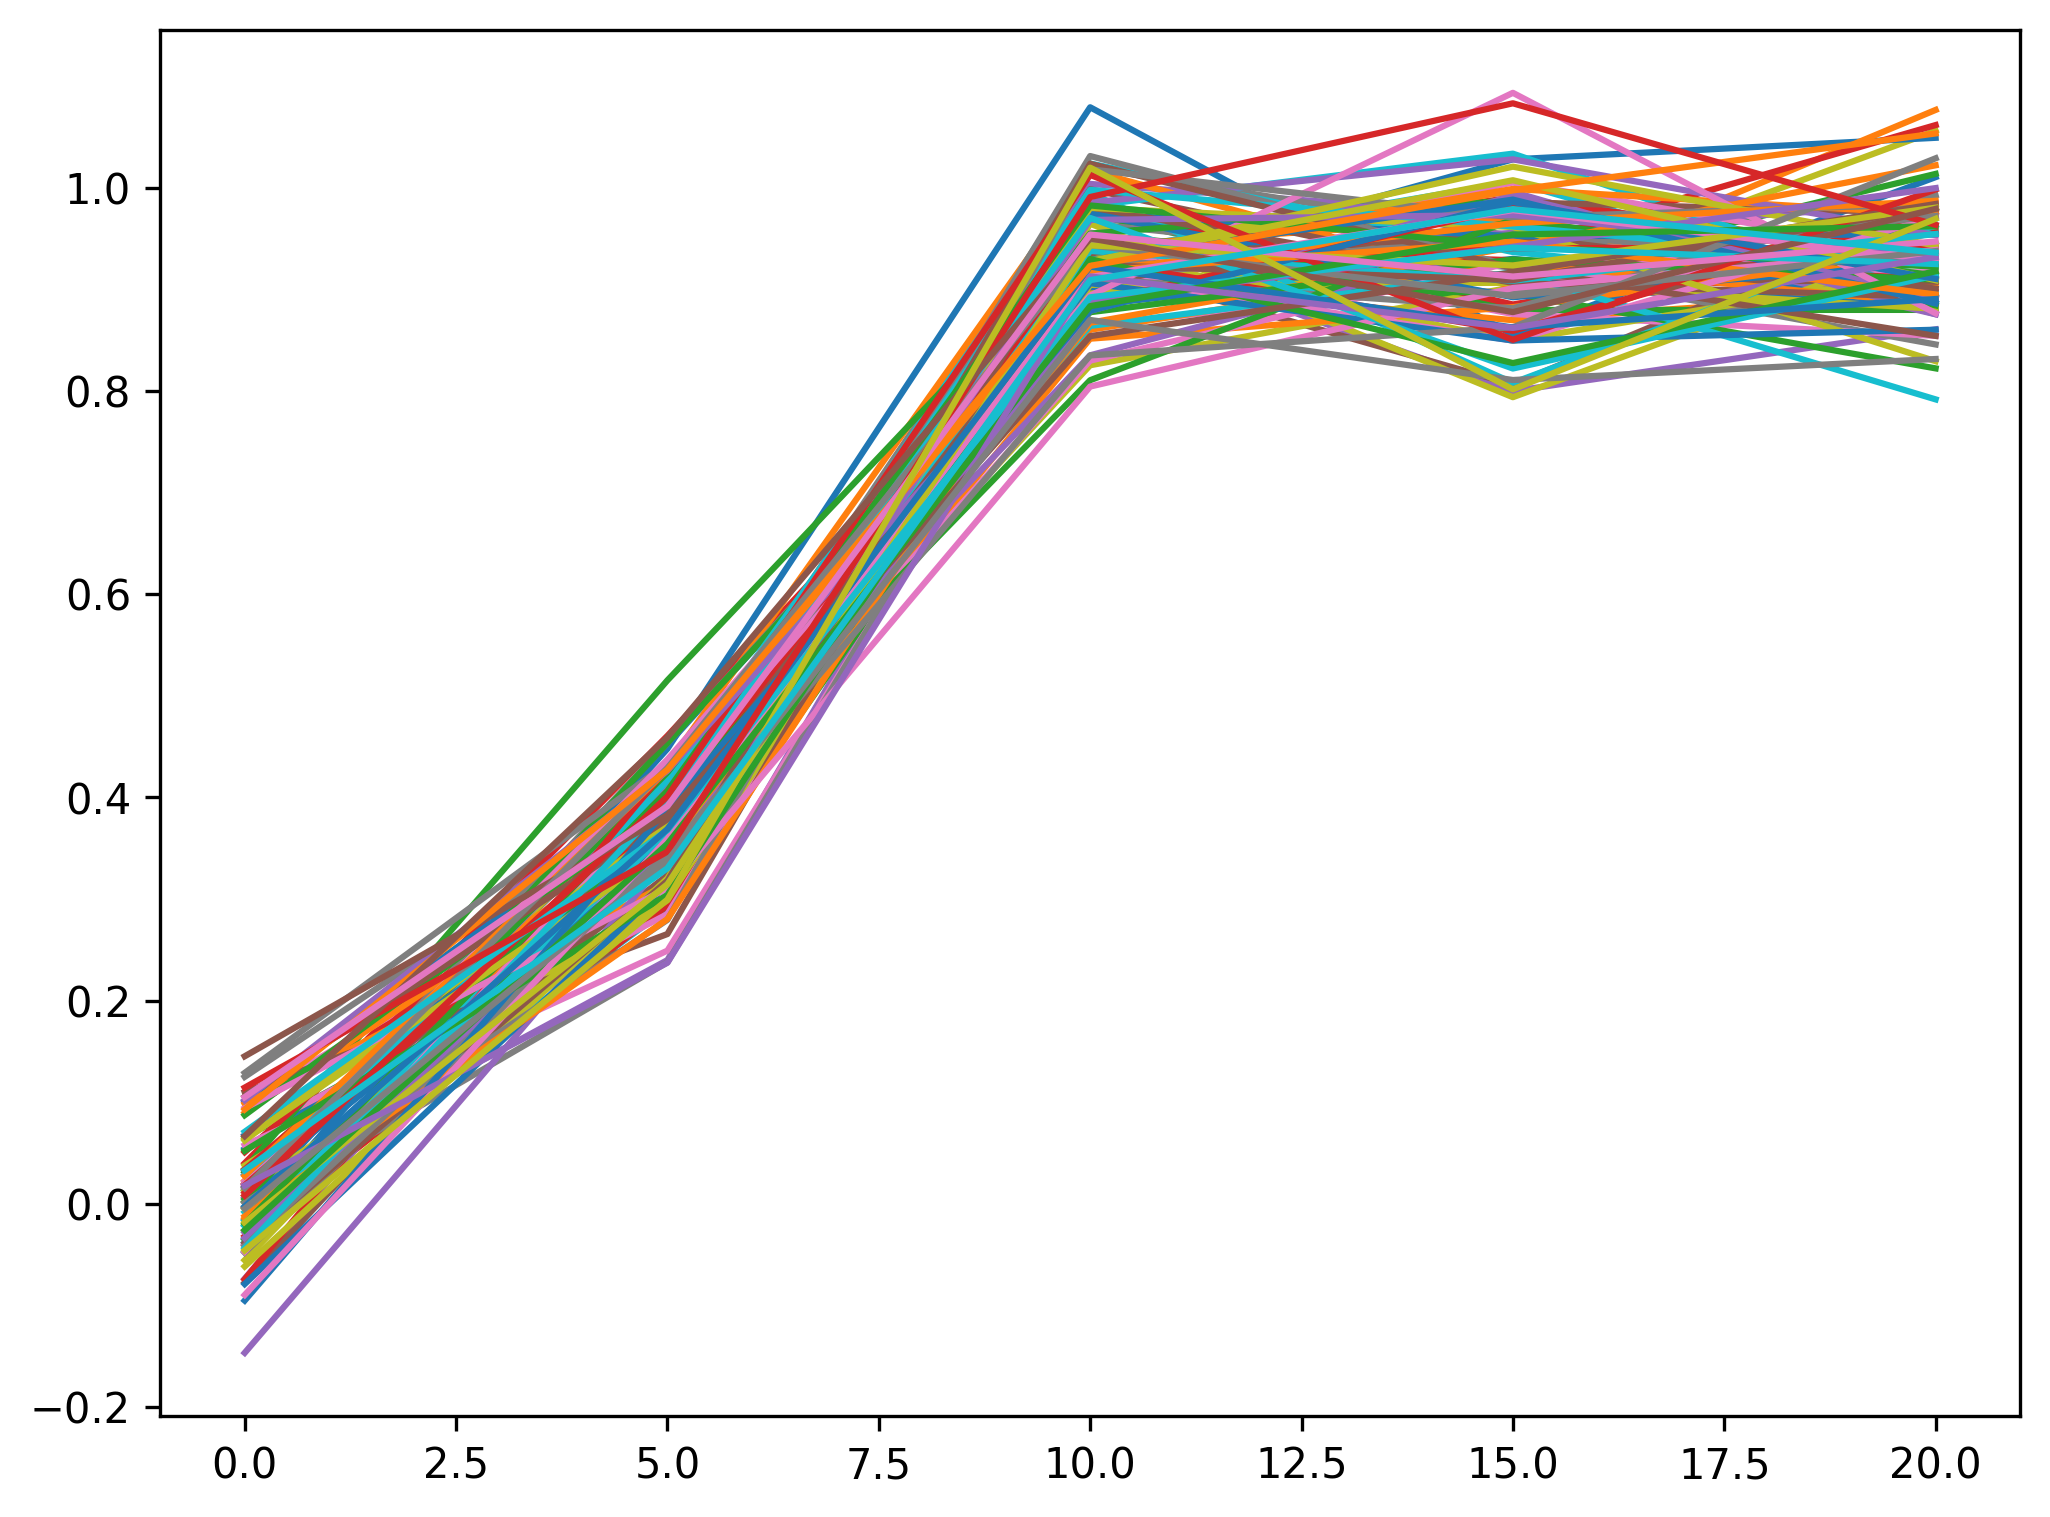

In [5]:
gp = {}
y_data_list = {}
for ii in range(num_eq):
    plt.figure(figsize=(6, 4.5), dpi=300)

    # Capture the start time
    start_time = time_module.time()

    # Assuming 'trajectories' and 't' are already defined and are numpy arrays
    y_train = traj_dict[ii].reshape(-1)
    t_train = np.tile(t, len(traj_dict[ii])).reshape(-1, 1)

    # Create a kernel with RBF for the smooth changes and WhiteKernel for the nugget effect (observation noise)
    #kernel = RBF(1, length_scale_bounds=(1e-10, 1e5)) + WhiteKernel(noise_level=1e-5, noise_level_bounds=(1e-10, 1e+5))
    kernel = RBF(1, length_scale_bounds=(1e-10, 1e5)) + WhiteKernel(noise_level=1e-5, noise_level_bounds=(1e-10, 1e+5))

    gp[ii] = GaussianProcessRegressor(kernel=kernel, normalize_y=True, alpha=0.5)
    gp[ii].fit(t_train, y_train)

    # Prepare the test data
    t_pred = np.linspace(t.min(), t.max(), 100).reshape(-1, 1)
    y_pred, sigma = gp[ii].predict(t_pred, return_std=True)

    # Plot the results
    plt.plot(t_pred, y_pred, label='Prediction')
    plt.fill_between(t_pred.flatten(), y_pred - 1.96 * sigma, y_pred + 1.96 * sigma, alpha=0.2, label='95% confidence interval')
    plt.scatter(t_train, y_train, c='k', s=20, label='Data', zorder=3)
    plt.xlabel('Time', fontsize=14)
    plt.ylabel('y(t)', fontsize=14)
    plt.title('Gaussian Process Regression', fontsize=16, fontweight='bold')
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.savefig('Fig1_b_mid.eps', format='eps', dpi=300)
    plt.show()


    # Capture the end time
    end_time = time_module.time()
    # Calculate the elapsed time
    elapsed_time = end_time - start_time

    print(f"The code took {elapsed_time} seconds to run.")

    # samples
    plt.figure(figsize=(8, 6), dpi=300)

    sample = 1000

    y_samples = gp[ii].sample_y(t.reshape(-1, 1), n_samples=sample)
    y_data_list[ii] = []
    for n in tqdm(range(sample)):
        y_data_list[ii].append(y_samples.T[n])
    for k in range(min([100,sample])):
        plt.plot(t, y_data_list[ii][k])

    plt.show()

In [6]:
A_initial = trainer.center.view(-1).detach().cpu().numpy()

In [7]:
y0 = trainer.Y_init
def model(y, t, ps):
    r,K = ps
    dydt = r*y*(1-y/K)
    #dydt = 0.01*r*y-0.1*K
    return dydt

def ode_forward(t, y0, ps):
    """
    Solution to the ODE x'(t) = f(t,x,k) with initial condition x(0) = x0
    """
    sol = odeint(model, y0, t, args=(ps,))
    return sol

def objective(ps,y0, ts, data):
    #y = ps['y1'].value, ps['y2'].value
    model = ode_forward(ts, y0, ps)
    error = data - model.reshape(-1)
    return np.sum(error**2)

A_list_gp = np.zeros((sample,trainer.num_p))
res_list_gp = np.zeros(sample)
#A_initial = np.mean(modes_noisy.numpy(),axis=0) 
#A_initial = np.zeros(trainer.num_p)

for n in tqdm(range(sample)):
    res = least_squares(objective, A_initial, args=(y0, t, np.concatenate([y_data_list[ii][n].reshape(-1,1) for ii in range(num_eq)],-1)))
#    res = least_squares(objective, A_initial, args=(y0, t, y_data_list_3[n]))
    A_list_gp[n] = res.x
    res_list_gp[n] = res.cost

  0%|                                                  | 0/1000 [00:00<?, ?it/s]/tmp/ipykernel_675454/3062026581.py:12: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  sol = odeint(model, y0, t, args=(ps,))
100%|███████████████████████████████████████| 1000/1000 [18:10<00:00,  1.09s/it]


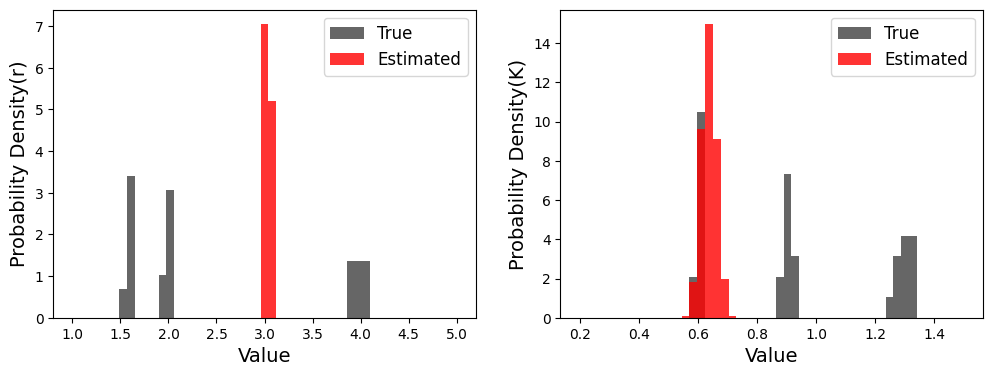

In [8]:
p_name= trainer.param_names
p_range = trainer.p_range
fig = plt.figure(figsize=(6*len(p_name),4))
for k in range(len(p_name)):
    ax = fig.add_subplot(100+10*len(p_name)+k+1)
    ax.hist(modes_noisy[:,:].numpy()[:, k], bins=np.linspace(p_range[k][0], p_range[k][1]), density=True, alpha=0.6, color='black')
    ax.hist(np.array(A_list_gp[:, k]), bins=np.linspace(p_range[k][0], p_range[k][1]), density=True, alpha=0.8, color='red')
    #ax.plot(x, p, 'k', linewidth=2)
    ax.legend(['True', 'Estimated'], fontsize=12)

    ax.set_xlabel('Value', fontsize=14)
    ax.set_ylabel('Probability Density({})'.format(p_name[k]), fontsize=14)
plt.show()

In [9]:
gens = torch.FloatTensor(A_list_gp)
torch.save(gens, './save/GP/gp_'+trainer.name+str(trainer.num_modes)+'.pth')